In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/zomato_cleaned.csv")

In [3]:
print("Dataset Shape:", df.shape)
print(df.head(3))

Dataset Shape: (3448, 22)
                   name                                                url  \
0        Sri Udupi Park  https://www.zomato.com/bangalore/sri-udupi-par...   
1         Meghana Foods  https://www.zomato.com/bangalore/meghana-foods...   
2  Donne Biriyani House  https://www.zomato.com/bangalore/donne-biriyan...   
3        Domino's Pizza  https://www.zomato.com/bangalore/dominos-pizza...   
4                   KFC   https://www.zomato.com/bangalore/kfc-indiranagar   

                                            cuisines                    area  \
0  south indian, north indian, chinese, street fo...  Indiranagar, Bangalore   
1             biryani, andhra, north indian, seafood  Indiranagar, Bangalore   
2                                            biryani  Indiranagar, Bangalore   
3                         pizza, fast food, desserts  Indiranagar, Bangalore   
4    burger, fast food, biryani, desserts, beverages  Indiranagar, Bangalore   

                        

In [4]:
print(df.describe())

       ishomedelivery   istakeaway  isindoorseating    isvegonly  \
count     3448.000000  3448.000000      3448.000000  3448.000000   
mean         0.999130     0.977088         0.921404     0.118910   
std          0.029488     0.149644         0.269147     0.323729   
min          0.000000     0.000000         0.000000     0.000000   
25%          1.000000     1.000000         1.000000     0.000000   
50%          1.000000     1.000000         1.000000     0.000000   
75%          1.000000     1.000000         1.000000     0.000000   
max          1.000000     1.000000         1.000000     1.000000   

       dinner_ratings  dinner_reviews  delivery_ratings  delivery_reviews  \
count     3448.000000     3448.000000       3448.000000       3448.000000   
mean         3.636688      366.133991          3.932338       3626.352088   
std          0.471438     1056.205709          0.277627       6997.316540   
min          2.000000        0.000000          2.600000          0.000000   
25

In [5]:
area_competition = df.groupby("area")["name"].count().sort_values(ascending=False)
print(area_competition.head(10))

area
HSR, Bangalore                187
Indiranagar, Bangalore        151
Electronic City, Bangalore    144
BTM, Bangalore                137
JP Nagar, Bangalore           136
Whitefield, Bangalore         130
Marathahalli, Bangalore       124
Jayanagar, Bangalore          120
New BEL Road, Bangalore        94
Kalyan Nagar, Bangalore        88
Name: name, dtype: int64


In [6]:
df["total_reviews"] = df["dinner_reviews"] + df["delivery_reviews"]

top_demand = df.sort_values("total_reviews", ascending=False).head(10)

print(top_demand[["name","area","total_reviews"]])

                         name                              area  total_reviews
337        Imperio Restaurant            Brookefield, Bangalore          84124
3126        Empire Restaurant            Indiranagar, Bangalore          81800
862   Falahaar & Kota Kachori  Koramangala 7th Block, Bangalore          80930
829         Empire Restaurant  Koramangala 5th Block, Bangalore          79917
846             Meghana Foods  Koramangala 5th Block, Bangalore          76728
2452       Imperio Restaurant           Kalyan Nagar, Bangalore          74113
1414          Ayodhya Upachar           Banashankari, Bangalore          72238
40                    Al Daaz                    HSR, Bangalore          65023
1380            Meghana Foods              Jayanagar, Bangalore          62895
878              Asha Tiffins                    HSR, Bangalore          61188


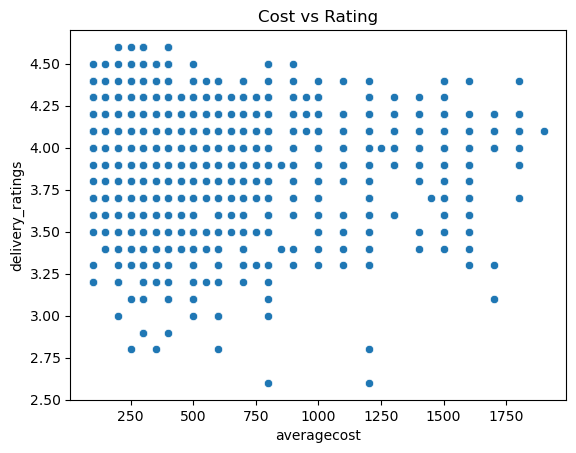

In [7]:
sns.scatterplot(x="averagecost", y="delivery_ratings", data=df)
plt.title("Cost vs Rating")
plt.show()

In [8]:
area_counts = df["area"].value_counts().head(10)

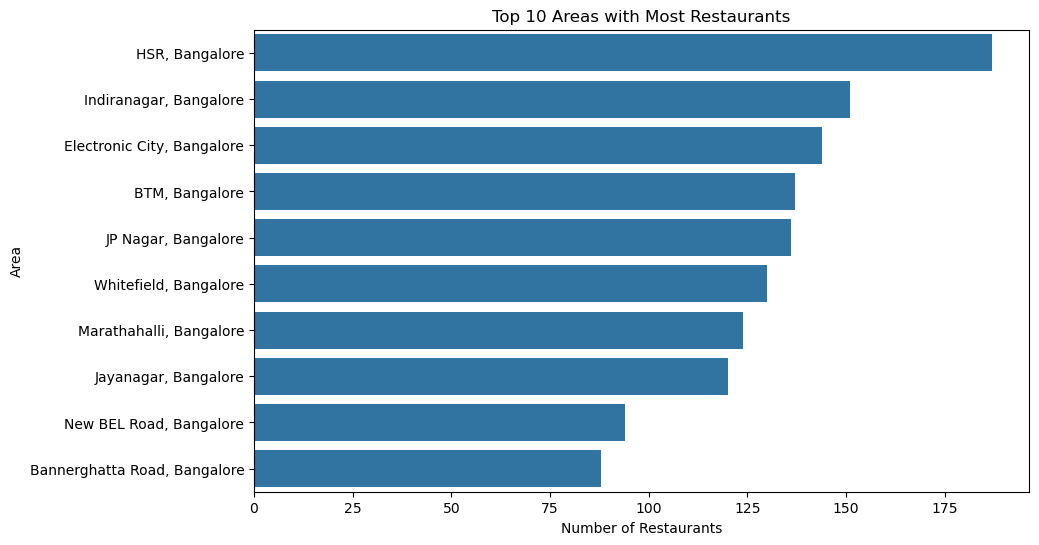

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x=area_counts.values, y=area_counts.index)
plt.title("Top 10 Areas with Most Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")
plt.show()

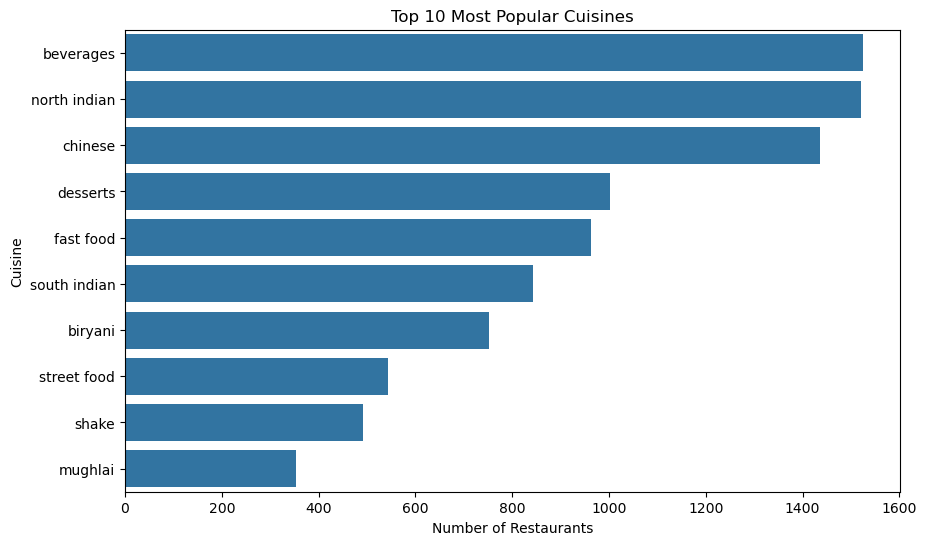

In [10]:
df["cuisines"] = df["cuisines"].astype(str)
df["cuisines"] = df["cuisines"].str.split(",")

cuisine_df = df.explode("cuisines")
cuisine_df["cuisines"] = cuisine_df["cuisines"].str.strip()

top_cuisines = cuisine_df["cuisines"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()


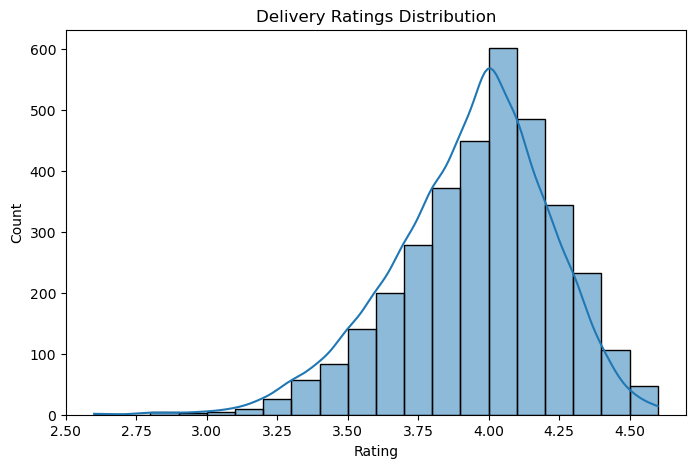

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_ratings"], bins=20, kde=True)
plt.title("Delivery Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

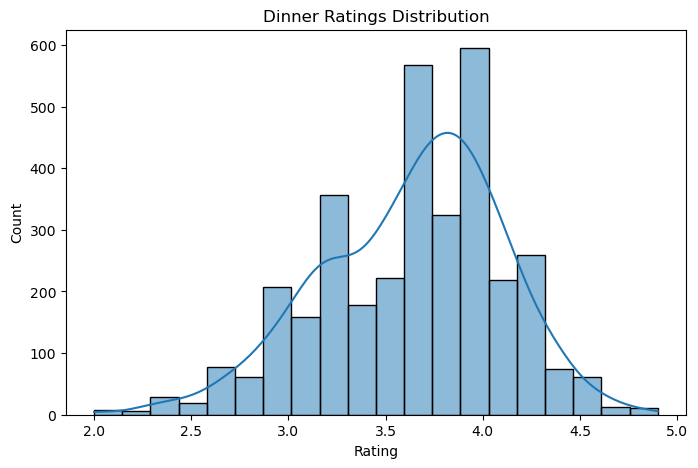

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["dinner_ratings"], bins=20, kde=True)
plt.title("Dinner Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

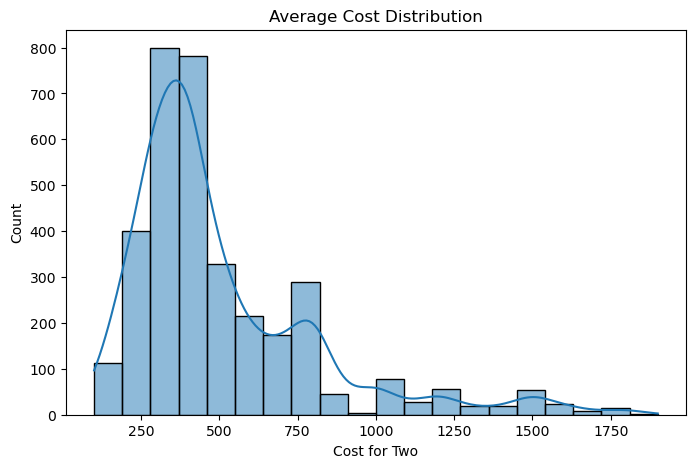

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["averagecost"], bins=20, kde=True)
plt.title("Average Cost Distribution")
plt.xlabel("Cost for Two")
plt.ylabel("Count")
plt.show()

In [14]:
df["total_reviews"] = df["dinner_reviews"] + df["delivery_reviews"]

top_demand = df.sort_values(by="total_reviews", ascending=False).head(10)

print(top_demand[["name","area","total_reviews"]])

                         name                              area  total_reviews
337        Imperio Restaurant            Brookefield, Bangalore          84124
3126        Empire Restaurant            Indiranagar, Bangalore          81800
862   Falahaar & Kota Kachori  Koramangala 7th Block, Bangalore          80930
829         Empire Restaurant  Koramangala 5th Block, Bangalore          79917
846             Meghana Foods  Koramangala 5th Block, Bangalore          76728
2452       Imperio Restaurant           Kalyan Nagar, Bangalore          74113
1414          Ayodhya Upachar           Banashankari, Bangalore          72238
40                    Al Daaz                    HSR, Bangalore          65023
1380            Meghana Foods              Jayanagar, Bangalore          62895
878              Asha Tiffins                    HSR, Bangalore          61188


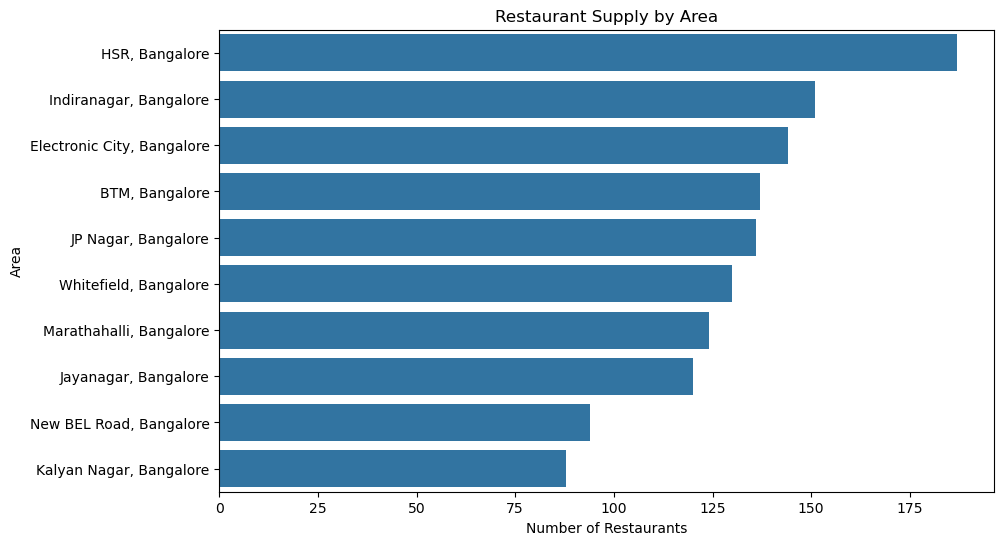

In [15]:
restaurant_supply = df.groupby("area")["name"].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=restaurant_supply.values, y=restaurant_supply.index)
plt.title("Restaurant Supply by Area")
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")
plt.show()

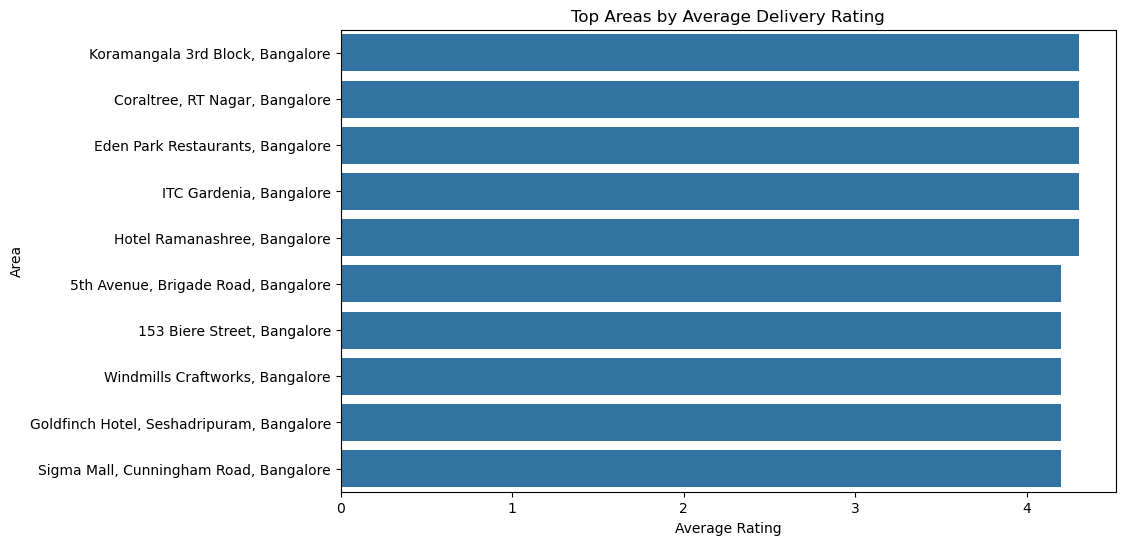

In [16]:
area_rating = df.groupby("area")["delivery_ratings"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=area_rating.values, y=area_rating.index)
plt.title("Top Areas by Average Delivery Rating")
plt.xlabel("Average Rating")
plt.ylabel("Area")
plt.show()

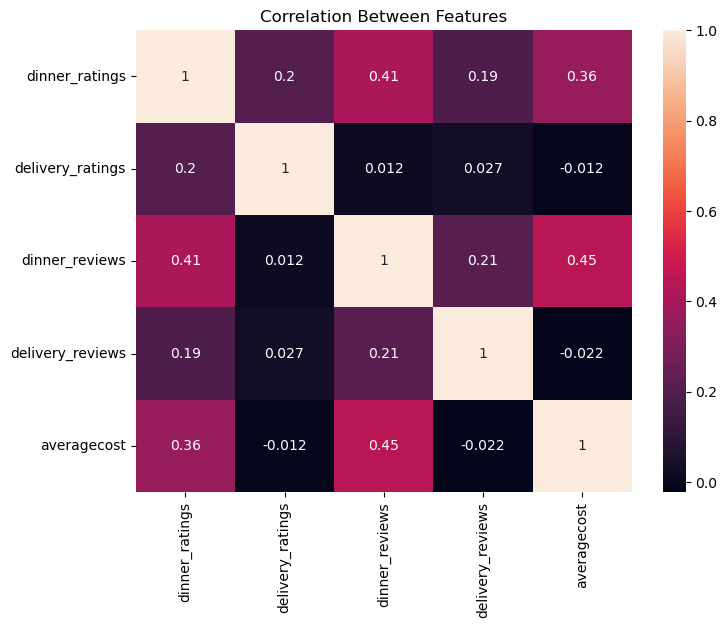

EDA Completed


In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df[[
    "dinner_ratings",
    "delivery_ratings",
    "dinner_reviews",
    "delivery_reviews",
    "averagecost"
]].corr(), annot=True)

plt.title("Correlation Between Features")
plt.show()

print("EDA Completed")